# 8. Embeddings clínics: comparació de models i cerca semàntica

Tractament de Dades Textuals i Codificades — Eixample Clínic, 2026

Pol Pastells, ppastells@eixampleclinic.es

**Objectius de la sessió:**
1. Entendre com funcionen els embeddings a la pràctica
2. Comparar models generals vs models clínics
3. Construir un cercador semàntic sobre notes clíniques reals (MPOC)
4. Explorar SapBERT per normalització d'entitats
5. Zero-shot classification com a pont cap al fine-tuning


## 0. Setup

In [ ]:
# !pip install sentence-transformers transformers datasets torch pandas scikit-learn protobuf sentencepiece plotly

In [ ]:
import numpy as np
import pandas as pd
import plotly.express as px
import torch
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Dispositiu: {device}")

## 1. Recap: què són els embeddings?

La sessió passada vam veure que els models de llenguatge converteixen text en vectors numèrics (**embeddings**).

Avui veurem:

- Com **diferents models** generen embeddings diferents
- Per què un model entrenat amb textos clínics pot ser millor per tasques clíniques
- Com aprofitar-ho per buscar informació en notes reals

In [ ]:
# Exemple senzill: frases clíniques amb significats similars i diferents
frases_exemple = [
    # Grupo 1: Exacerbación / empeoramiento respiratorio
    "El paciente presenta una exacerbación aguda de su EPOC",
    "Empeoramiento brusco de la disnea con aumento de la expectoración",
    "Agudización respiratoria que requiere hospitalización",
    # Grupo 2: Estabilidad clínica
    "El paciente se encuentra estable, sin cambios respecto a la visita anterior",
    "Buena evolución, mantiene saturación de oxígeno correcta",
    "Control rutinario sin incidencias destacables",
    # Grupo 3: Tratamiento farmacológico
    "Se inicia tratamiento con broncodilatadores y corticoides inhalados",
    "Se prescribe salbutamol a demanda y fluticasona de mantenimiento",
    "Ajuste de medicación: aumentar dosis de tiotropio",
]
# Per si voleu mirar com va en català
frases_exemple_ca = [
    "El pacient presenta una exacerbació aguda de la seva MPOC",
    "Empitjorament brusc de la dispnea amb augment de l'expectoració",
    "Agudització respiratòria que requereix hospitalització",
    "El pacient es troba estable, sense canvis respecte a la visita anterior",
    "Bona evolució, manté saturació d'oxigen correcta",
    "Control rutinari sense incidències destacables",
    "S'inicia tractament amb broncodilatadors i corticoides inhalats",
    "Es prescriu salbutamol a demanda i fluticasona de manteniment",
    "Ajust de medicació: augmentar dosi de tiotropi",
]
grups = ["Exacerbació"] * 3 + ["Estabilitat"] * 3 + ["Tractament"] * 3
colors_grup = {"Exacerbació": "red", "Estabilitat": "green", "Tractament": "blue"}

## 2. Model general multilingüe

`paraphrase-multilingual-MiniLM-L12-v2`:

- Entrenat amb textos generals (Wikipedia, fòrums, etc.)
- Multilingüe (inclou català i castellà)
- Lleuger (~470MB) i ràpid en CPU
- Molt usat com a baseline

In [ ]:
from sentence_transformers import SentenceTransformer

model_general = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2", device=device)
print(f"Dimensió embeddings: {model_general.get_sentence_embedding_dimension()}")

In [ ]:
embs_general = model_general.encode(frases_exemple, show_progress_bar=True)
embs_general.shape

In [ ]:
sim_general = cosine_similarity(embs_general)

labels = [f"{i}: {f[:45]}..." for i, f in enumerate(frases_exemple)]
fig = px.imshow(
    sim_general,
    x=labels,
    y=labels,
    color_continuous_scale="RdBu_r",
    zmin=0,
    zmax=1,
    title="Similitud — Model GENERAL (multilingual-MiniLM)",
    labels=dict(color="cosinus"),
)
fig.update_layout(width=900, height=700, xaxis_tickangle=45)
fig.show()

❓ **Mireu la matriu:** Es veuen clarament els 3 grups? Hi ha frases de grups diferents que surten molt similars?

## Interludi teòric: BERT vs GPT — per què encara fem servir encoders?

Abans d'entrar a SapBERT, parem un moment. **SapBERT és un BERT**. Però... no vivim a l'era dels LLMs tipus GPT, Claude, Llama? Per què seguim utilitzant models "petits" tipus BERT?

### L'arquitectura Transformer original (2017)

El paper *"Attention is All You Need"* va proposar una arquitectura amb **dues parts**:

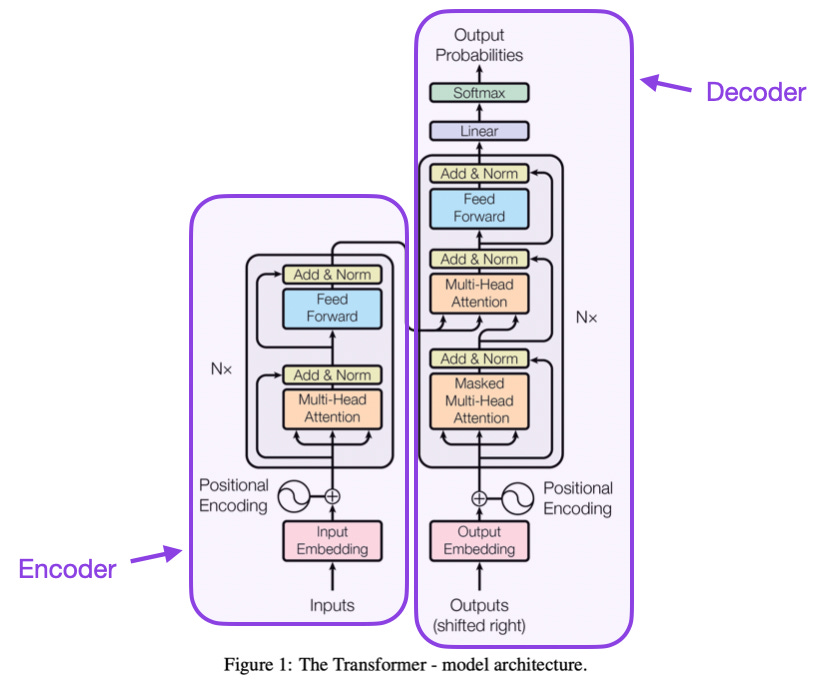
(imatge de https://sebastianraschka.com/)

- **Encoder** (esquerra): llegeix tot el text alhora i en construeix una representació rica. Cada token pot "mirar" tots els altres (atenció bidireccional).
- **Decoder** (dreta): genera text token a token, mirant només els tokens anteriors (atenció causal/unidireccional).

De seguida algú va pensar: *"i si fem servir només una de les dues parts?"*

### Dues famílies de models

| | **Encoder-only (BERT)** | **Decoder-only (GPT)** |
|---|---|---|
| **Atenció** | Bidireccional (veu tot el context) | Causal (només mira enrere) |
| **Entrenament** | Masked Language Modeling: omplir forats | Next token prediction |
| **Entrada** | `"El pacient té [MASK] pulmonar"` → *infecció* | `"El pacient té"` → *febre, tos, ...* |
| **Output natural** | Vector de representació | Text generat |
| **Mida típica** | 100M–400M paràmetres | 7B–500B+ paràmetres |
| **Exemples** | BERT, RoBERTa, SapBERT, ModernBERT | GPT-4, Claude, Llama, Mistral |

### Per què BERT encara és rellevant el 2025?

Tot i l'explosió dels LLMs, els encoders segueixen dominant molts casos d'ús:

**1. Velocitat i cost**
Un BERT fa inferència en **milisegons** en una CPU. Un LLM necessita GPU i triga segons.

**2. Representacions denses (embeddings)**
Els encoders estan **dissenyats** per produir un vector que representi tot el text. Els decoders no — el seu objectiu és generar el següent token, no resumir el significat. Per tasques com:
- Cerca semàntica
- Clustering de documents
- Normalització d'entitats (SapBERT)
- Similitud entre textos

...un encoder és la tria natural.

**3. Classificació i NER**
Per classificar un text o etiquetar entitats, no necessites generar text. Només necessites un bon vector per cada token. Un BERT fine-tunejat supera sovint un LLM en aquestes tasques.

**4. Privacitat i on-premise**
Un model de 300M paràmetres es pot desplegar dins l'hospital sense problemes. Un LLM de 70B... complicat.

**5. Fine-tuning barat**
Pots fer fine-tuning d'un BERT amb una GPU modesta i poques hores. Per un LLM necessites infraestructura seriosa (o tècniques com LoRA).

### TLDR

- **LLMs** = generació, raonament, diàleg, tasques obertes
- **Encoders (tipus BERT)** = representació, classificació, cerca, eficiència

En un pipeline clínic real, **sovint fem servir els dos**: un encoder per filtrar/cercar/classificar ràpidament milers de documents, i un LLM per generar resums o respostes quan cal.

I ara sí, anem a veure **SapBERT**: un encoder especialitzat en terminologia biomèdica.

## 3. Model clínic: SapBERT en castellà

**SapBERT** (*Self-Alignment Pretraining for BERT*):

- Entrenat amb sinònims d'UMLS (Unified Medical Language System; base de dades terminològica mèdica)
- Aprèn que "EPOC" i "enfermedad pulmonar obstructiva crónica" són el mateix
- El de BSC està basat en RoBERTa clínic en castellà

⚠️ SapBERT **no** és un model tipus transfomer. Primer veurem com s'usa "per dins", i després farem un wrapper com a sentence-transformer.

In [ ]:
from transformers import AutoModel, AutoTokenizer

sapbert_name = "BSC-NLP4BIA/SapBERT-from-roberta-base-biomedical-clinical-es"
tokenizer_sap = AutoTokenizer.from_pretrained(sapbert_name)
model_sap = AutoModel.from_pretrained(sapbert_name).to(device)
print("SapBERT carregat!")

In [ ]:
def encode_sapbert_manual(textos, tokenizer, model, max_length=128, batch_size=16):
    """Codifica textos amb SapBERT usant el token [CLS] com a representació."""
    all_embs = []
    for i in range(0, len(textos), batch_size):
        batch = textos[i : i + batch_size]
        toks = tokenizer(
            batch,
            padding="max_length",
            max_length=max_length,
            truncation=True,
            return_tensors="pt",
        )
        toks = {k: v.to(device) for k, v in toks.items()}
        with torch.no_grad():
            output = model(**toks)
        cls_emb = output.last_hidden_state[:, 0, :]
        all_embs.append(cls_emb.cpu().numpy())
    return np.concatenate(all_embs, axis=0)


embs_sapbert_manual = encode_sapbert_manual(frases_exemple, tokenizer_sap, model_sap)
embs_sapbert_manual.shape

Això és molt codi! Podem embolcallar-ho amb `sentence-transformers`:

In [ ]:
from sentence_transformers import models

word_model = models.Transformer(sapbert_name)
pooling = models.Pooling(
    word_model.get_word_embedding_dimension(),
    pooling_mode="cls",  # CLS token, igual que el BSC
)
model_sapbert = SentenceTransformer(modules=[word_model, pooling], device=device)
print(f"Dimensió: {model_sapbert.get_sentence_embedding_dimension()}")

In [ ]:
embs_sapbert = model_sapbert.encode(frases_exemple, show_progress_bar=True)

# Verifiquem que els dos mètodes donen el mateix resultat
sims = [cosine_similarity([embs_sapbert_manual[i]], [embs_sapbert[i]])[0][0] for i in range(len(frases_exemple))]
print("Similitud manual vs wrapper (ha de ser ~1.0):")
for i, s in enumerate(sims):
    print(f"  Frase {i}: {s:.6f}")

In [ ]:
sim_sapbert = cosine_similarity(embs_sapbert)
fig = px.imshow(
    sim_sapbert,
    x=labels,
    y=labels,
    color_continuous_scale="RdBu_r",
    zmin=0,
    zmax=1,
    title="Similitud — Model CLÍNIC (SapBERT castellà)",
    labels=dict(color="cosinus"),
)
fig.update_layout(width=900, height=700, xaxis_tickangle=45)
fig.show()

❓ **Compareu les dues matrius.** Quin model separa millor els 3 grups? Recordeu: SapBERT està pensat per **termes curts** (entitats), no per frases llargues. Es nota?

## 4. Visualització 2D dels embeddings

Els embeddings tenen 384 o 768 dimensions — no podem visualitzar-los directament. Projectem a 2D amb PCA.

In [ ]:
def plot_embeddings_2d(embs, frases, grups, title):
    """Projecta embeddings a 2D amb PCA i els mostra."""
    pca = PCA(n_components=2)
    coords = pca.fit_transform(embs)

    df_plot = pd.DataFrame({"x": coords[:, 0], "y": coords[:, 1], "frase": [f[:80] for f in frases], "grup": grups})

    fig = px.scatter(
        df_plot,
        x="x",
        y="y",
        color="grup",
        hover_data=["frase"],
        title=title,
        color_discrete_map=colors_grup,
        width=800,
        height=500,
    )
    fig.update_traces(marker=dict(size=12))
    fig.show()

    var_explicada = sum(pca.explained_variance_ratio_) * 100
    print(f"Variància explicada (2 components): {var_explicada:.1f}%")

In [ ]:
plot_embeddings_2d(embs_general, frases_exemple, grups, "Model GENERAL (multilingual-MiniLM)")

In [ ]:
plot_embeddings_2d(embs_sapbert, frases_exemple, grups, "Model CLÍNIC (SapBERT castellà)")

## 5. Dades reals: notes clíniques MPOC

Ara amb dades reals! Carreguem el dataset de notes clíniques d'MPOC.

In [ ]:
notes = pd.read_csv("data/CLASSIFICACIÓ_NOTES_CLINIQUES.csv", sep=";")

test = notes[notes.exacerbacio.isna()].copy()
df = notes[~notes.exacerbacio.isna()].copy()

df.exacerbacio = df.exacerbacio.map({"SI": 1, "si": 1, "NO": 0})
df.idioma_dominant = df.idioma_dominant.map({"CATALÀ": "ca", "ESPANYOL": "es"})
assert df.idioma_dominant.isna().sum() == 0

for col in ("text", "motiu", "exploracio", "avaluacio", "pla"):
    df[col] = df[col].str.lower().str.replace("\n", " ")

df.head()

In [ ]:
print(f"Train: {df.shape}, Test (sense etiqueta): {test.shape}")
print("\nDistribució exacerbació:")
print(df.exacerbacio.value_counts())
print("\nDistribució idioma:")
print(df.idioma_dominant.value_counts())

In [ ]:
# Treballem amb una mostra per velocitat en CPU
MOSTRA = 100
df_mostra = (
    df[df.idioma_dominant == "es"]  # si volem només esp
    .sample(n=min(MOSTRA, len(df)), random_state=1)
    .reset_index(drop=True)
)  # noqa
textos = df_mostra["text"].fillna("").tolist()

print(f"Treballant amb {len(textos)} notes")
print(f"\nExemple de nota:\n{textos[0][:500]}")

In [ ]:
print("Codificant amb model general...")
embs_general_mpoc = model_general.encode(textos, show_progress_bar=True, batch_size=16)

print("Codificant amb SapBERT...")
embs_sapbert_mpoc = model_sapbert.encode(textos, show_progress_bar=True, batch_size=16)

print(f"\nGeneral: {embs_general_mpoc.shape}")
print(f"SapBERT: {embs_sapbert_mpoc.shape}")

## 6. Cercador semàntic

Escrivim una consulta en llenguatge natural i el model troba les notes més similars.

In [ ]:
def cercar(consulta, model, embeddings_notes, textos, top_k=3):
    emb_consulta = model.encode([consulta])
    similituds = cosine_similarity(emb_consulta, embeddings_notes)[0]
    top_idx = similituds.argsort()[::-1][:top_k]
    print(f'🔍 Consulta: "{consulta}"\n' + "=" * 80)
    for rank, idx in enumerate(top_idx, 1):
        print(f"\n📄 Resultat {rank} (sim: {similituds[idx]:.4f})")
        print(f"   {textos[idx][:300]}...")
        print("-" * 80)
    return top_idx

In [ ]:
consulta = "pacient amb empitjorament respiratori agut i augment de la tos"
consulta = "paciente con problemas respiratorios agudos i aumento de la tos"

print("### MODEL GENERAL ###")
cercar(consulta, model_general, embs_general_mpoc, textos)

In [ ]:
print("### SapBERT ###")
cercar(consulta, model_sapbert, embs_sapbert_mpoc, textos)

In [ ]:
# Provem altres consultes
consultes_ca = [
    "tractament amb oxigen domiciliari",
    "pacient fumador actiu",
    "infecció respiratòria amb febre i expectoració purulenta",
    "espirometria amb obstrucció greu",
]
consultes = [
    "tratamiento con oxígeno domiciliario",
    "paciente fumador activo",
    "infección respiratoria con fiebre y expectoración purulenta",
    "espirometría con obstrucción grave",
]


for c in consultes:
    print("--- Model General ---")
    cercar(c, model_general, embs_general_mpoc, textos, top_k=2)
    print("\n--- SapBERT ---")
    cercar(c, model_sapbert, embs_sapbert_mpoc, textos, top_k=2)

❓ **Discussió:**

- Quin model retorna resultats més rellevants?
- SapBERT està pensat per entitats curtes (noms de malalties, fàrmacs). Es nota en frases llargues?
- Quin model farieu servir per un cercador de notes clíniques?

## 7. SapBERT per normalització d'entitats

El cas d'ús **real** de SapBERT: donat un terme clínic escrit de qualsevol manera, trobar l'entitat estàndard corresponent.

Exemples:
- `"EPOC"` → `"Enfermedad Pulmonar Obstructiva Crónica"`
- `"azúcar alta"` → `"Hiperglucemia"`

In [ ]:
# Mini-diccionari clínic
termes_estandard = [
    "Enfermedad pulmonar obstructiva crónica",
    "Exacerbación de EPOC",
    "Neumonía",
    "Insuficiencia cardíaca",
    "Hipertensión arterial",
    "Diabetes mellitus tipo 2",
    "Asma bronquial",
    "Embolia pulmonar",
    "Infección respiratoria",
    "Insuficiencia respiratoria",
    "Bronquitis crónica",
    "Enfisema pulmonar",
    "Fibrosis pulmonar",
    "Apnea del sueño",
    "Cor pulmonale",
    "Tabaquismo",
    "Hiperglucemia",
    "Anemia",
    "Obesidad",
    "Desnutrición",
]
embs_diccionari_sap = model_sapbert.encode(termes_estandard)
embs_diccionari_gen = model_general.encode(termes_estandard)
print(f"Diccionari: {len(termes_estandard)} termes")

In [ ]:
# Termes tal com els escriuria un metge ràpidament
termes_lliures = [
    "MPOC reaguditzada",
    "azúcar alta",
    "no dorm bé, ronca molt",
    "pulmó inflat",
    "fumador actiu",
    "li costa respirar",
    "infecció al pit",
    "tensió alta",
    "prim i desnutrit",
]

embs_lliures_sap = model_sapbert.encode(termes_lliures)
embs_lliures_gen = model_general.encode(termes_lliures)

sim_sap = cosine_similarity(embs_lliures_sap, embs_diccionari_sap)
sim_gen = cosine_similarity(embs_lliures_gen, embs_diccionari_gen)

In [ ]:
print("COMPARACIÓ: Model general vs SapBERT")
print("=" * 80)
for i, terme in enumerate(termes_lliures):
    top_sap = termes_estandard[sim_sap[i].argmax()]
    top_gen = termes_estandard[sim_gen[i].argmax()]
    match = "✅" if top_sap == top_gen else "⚠️"
    print(f'\n{match} "{terme}"')
    print(f"   General:  {top_gen} ({sim_gen[i].max():.4f})")
    print(f"   SapBERT:  {top_sap} ({sim_sap[i].max():.4f})")

❓ **On veieu les diferències més grans?** SapBERT hauria de ser millor amb sinonímia mèdica. Es compleix?

## 8. Zero-shot classification: podem detectar exacerbacions?

Ara intentem una cosa ambiciosa: **detectar si una nota descriu una exacerbació, sense entrenar el model.**

*Zero-shot* = donem etiquetes en text i el model decideix quina encaixa millor.

In [ ]:
from transformers import pipeline

classifier_zs = pipeline(
    "zero-shot-classification",
    model="joeddav/xlm-roberta-large-xnli",  # Multilingüe
    device=0 if device == "cuda" else -1,
)
print("Model zero-shot carregat!")

In [ ]:
# Provem amb exemples clars
etiquetes = ["exacerbació respiratòria", "visita de control estable"]

exemples_test_ca = [
    "Pacient que acudeix per augment de la dispnea i expectoració purulenta des de fa 3 dies",
    "Control rutinari. Pacient estable, sense canvis en la medicació",
    "Ingrés per agudització greu de MPOC amb necessitat d'oxigen",
    "Revisió semestral. Espirometria estable. Segueix el tractament correctament",
]
exemples_test = [
    "Paciente que acude por aumento de la disnea y expectoración purulenta desde hace 3 días",
    "Control rutinario. Paciente estable, sin cambios en la medicación",
    "Ingreso por agudización grave de EPOC con necesidad de oxígeno",
    "Revisión semestral. Espirometría estable. Sigue el tratamiento correctamente",
]


for text in exemples_test:
    result = classifier_zs(text, etiquetes)
    print(f"\n📄 {text[:80]}...")
    for label, score in zip(result["labels"], result["scores"]):
        bar = "█" * int(score * 30)
        print(f"   {label:40s} {score:.3f} {bar}")

In [ ]:
# Provem amb notes reals del dataset MPOC
# Agafem notes equilibrades: 10 d'exacerbació + 10 de control
notes_exac = df[df.exacerbacio == 1]["text"].dropna().head(10).tolist()
notes_ctrl = df[df.exacerbacio == 0]["text"].dropna().head(10).tolist()

print(f"Provant amb {len(notes_exac)} exacerbacions i {len(notes_ctrl)} controls")

resultats = []
for nota, label_real in [(n, 1) for n in notes_exac] + [(n, 0) for n in notes_ctrl]:
    nota_curta = nota[:512]
    pred = classifier_zs(nota_curta, etiquetes)
    score_exac = pred["scores"][pred["labels"].index("exacerbació respiratòria")]
    resultats.append(
        {
            "real": label_real,
            "score_exac": score_exac,
            "prediccio": 1 if score_exac > 0.5 else 0,
        }
    )

df_res = pd.DataFrame(resultats)

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, confusion_matrix

# Matriu de confusió
cm = confusion_matrix(df_res["real"], df_res["prediccio"], labels=[0, 1])

fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No exacerbació", "Exacerbació"],
)
disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
ax.set_title("Matriu de confusió — Zero-shot")
ax.set_xlabel("Predicció")
ax.set_ylabel("Real")
plt.tight_layout()
plt.show()

# Accuracy
accuracy = accuracy_score(df_res["real"], df_res["prediccio"])
print(f"Accuracy: {accuracy:.1%}")
print("\n⚠️  Segurament no és perfecte... i per això existeix el FINE-TUNING!")

### 💡 Exercicis

1. Proveu el cercador amb consultes vostres — quin model funciona millor?
2. Afegiu més termes al diccionari de normalització
3. Proveu el zero-shot amb etiquetes diferents (infecció/no infecció, fumador/exfumador/no fumador...)